# Focal Length Intersections and deviations under the Three Approximations
1. Normalized to (y0/rb) and x (c/wp)
2. Normalized to (y0/rb) and x (mm)

The slope of the high electron is = 1.3377e-03
The focal length of the high electron is =3.2662e-02

The slope of the low electron is =1.0442e-03
The focal length of the low electron is =3.1381e-02

Point of Intersection(f_tilda): 3.7222e-02 meters
Height of Intersection:-6.0994e-06 meters

Distance between f_tilda and f_tilda at small dy= 2.3968e-01 cm
Distance between f_tilda and f_tilda near midline= 2.7374e-01 cm

y0 = 3.2769e-05 meters
dy = 1.0923e-05 meters

The firt approximation is better
0.3


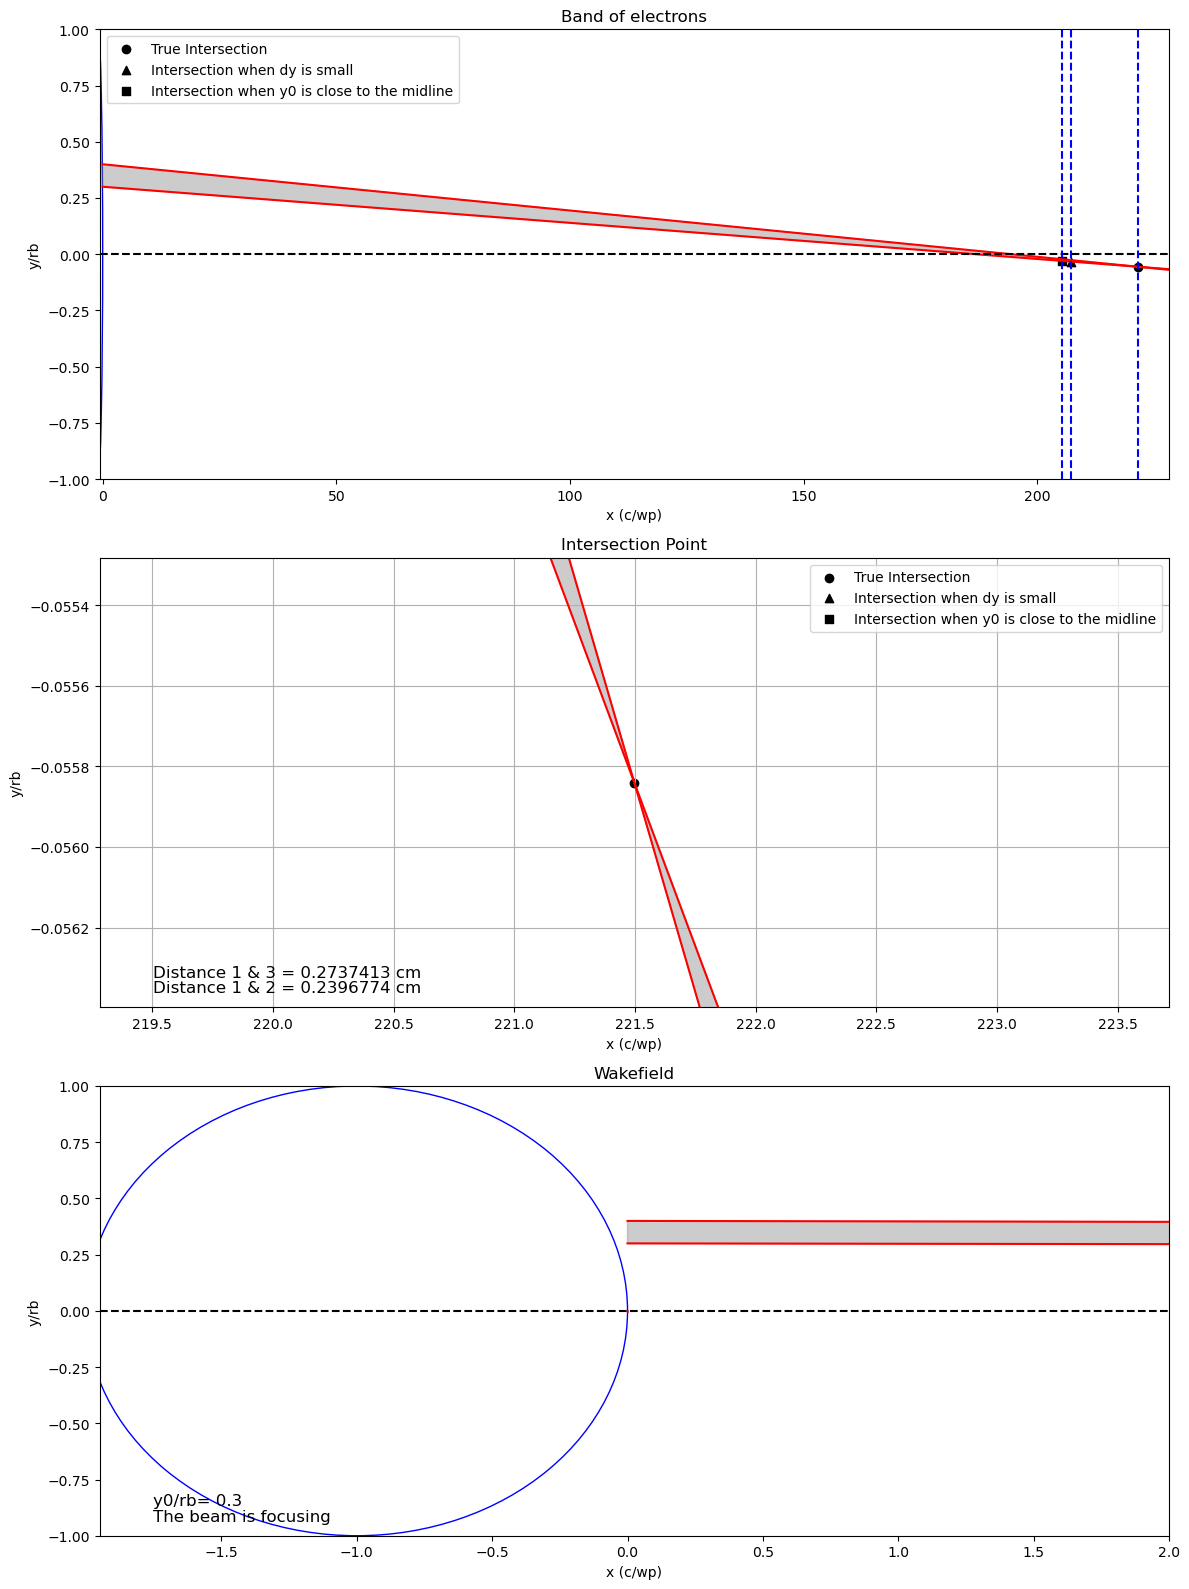

In [1]:
#Bryson Mariano
#5/29/2026

import numpy as np
import scipy.constants as constants
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import math

#Universal Parameters
me    = 9.1093837 * 10 ** (-31)  #kg
c     = 299792458.0              #m/s
ne    = 1 * 10.0**15 *10**6                 #number density
e0    = 8.85418782 * 10**(-12)   #m^-3 kg^-1s^4 A^2
e     = 1.60217663 * 10**(-19)   #coulombs
wp    = ((ne*e**2)/(me*e0)) ** (1/2)


#Define Parameters


gamma = 110                      #Unitless
k     = 0.475 *me*wp**2          #kg/s^2
rb    = 0.65  *c/wp               #c/omega_p   
px    = 110   *me*c                #mec

f0=((px)**2) / (gamma * me * k)


################################################################


y0rb= 0.3
dyrb= 0.1

y0 = y0rb*rb
dy = dyrb*rb



################################################################
#Create/define Focal Length Function

def f_cyl(i):
    return ( f0/(2*rb) *1/(np.sqrt(1-(i/rb)**2)))

def f_cylprime(i):
    return ( f0 /(2*rb) * (1-(i/rb)**2)**(-3/2) * (i/rb**2)  )
              

#############################################################

x = np.linspace(0, 2, 1000)

electron_low = -(y0/(f_cyl(y0)))*x +y0 

electron_high = - ((y0+dy)/(f_cyl(y0+dy)))*x + y0+dy 


##############################################################
#F-tilda Points 

f_Tilda = f_cyl(y0)*f_cyl(y0+dy)/(f_cyl(y0)-y0*(f_cyl(y0+dy)-f_cyl(y0))/dy) 

Intersect_y = -(y0/(f_cyl(y0)))*f_Tilda +y0

#dy goes to zero 
f_Tilda2 = f_cyl(y0)/(1-y0*(f_cylprime(y0)/f_cyl(y0)))

Intersect_y2 = -(y0/(f_cyl(y0)))* f_Tilda2 +y0


#Binomial Approx            
f_Tilda3 = f_cyl(y0)*(1+y0*(f_cylprime(y0)/f_cyl(y0))) 

Intersect_y3 = -(y0/(f_cyl(y0)))*f_Tilda3 +y0


#Distance Between Intersection Points
dist1_cm = np.sqrt((f_Tilda2 - f_Tilda)**2 + (Intersect_y2 - Intersect_y)**2) *100
dist2_cm = np.sqrt((f_Tilda3 - f_Tilda)**2 + (Intersect_y3 - Intersect_y)**2) *100


###########################################################################
#Slopes and focal lengths
print(f"The slope of the high electron is = {(y0+dy)/(f_cyl(y0+dy)):.4e}")
print(f"The focal length of the high electron is ={f_cyl(y0+dy):.4e}")
print()
print(f"The slope of the low electron is ={(y0)/f_cyl(y0):.4e}")
print(f"The focal length of the low electron is ={f_cyl(y0):.4e}")

print()
print(f"Point of Intersection(f_tilda): {f_Tilda:.4e} meters")
print(f"Height of Intersection:{Intersect_y:.4e} meters")
print()
print(f"Distance between f_tilda and f_tilda at small dy= {dist1_cm:.4e} cm")
print(f"Distance between f_tilda and f_tilda near midline= {dist2_cm:.4e} cm")
print()
print(f"y0 = {y0:.4e} meters")
print(f"dy = {dy:.4e} meters")
print()
if dist1_cm < dist2_cm:
    print("The firt approximation is better")
else:
    print("The second approximation is better")
print(y0/rb)


#Normalization:             #######################################################
x = x/(c/wp)
f_Tilda = f_Tilda /(c/wp)
f_Tilda2 = f_Tilda2 /(c/wp)
f_Tilda3 = f_Tilda3 /(c/wp)
Intersect_y = Intersect_y /rb
Intersect_y2 = Intersect_y2 /rb
Intersect_y3 = Intersect_y3 /rb
electron_low = electron_low /rb
electron_high = electron_high /rb
#############################################################################
#make subplots

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 16))

#############################################################################
#Figure 1 shows the wakefield and lines

circle = plt.Circle((-rb/rb, 0), 1, color='blue', fill=False)

# 3. Add the patch to the axis
ax1.add_patch(circle)


ax1.plot(x, electron_low, 'red')
ax1.plot(x, electron_high, 'red')
ax1.axhline(y=0, color='black', linestyle='--')

#f tilda Intersect point no approx     
ax1.scatter(f_Tilda, Intersect_y, color="black", marker="o", label='True Intersection')
ax1.axvline(x=f_Tilda, color='b', linestyle='--')

#f tilda Intersect point 1 approx     
ax1.scatter(f_Tilda2, Intersect_y2, color="black", marker="^", label='Intersection when dy is small')
ax1.axvline(x=f_Tilda2, color='b', linestyle='--')

#f tilda Intersect point 2 approx     
ax1.scatter(f_Tilda3, Intersect_y3, color="black", marker="s",  label='Intersection when y0 is close to the midline')
ax1.axvline(x=f_Tilda3, color='b', linestyle='--')


#Line distance
#ax1.plot([f_Tilda, f_Tilda2], [Intersect_y, Intersect_y2], color='green', linestyle='--')
#ax1.plot([f_Tilda, f_Tilda3], [Intersect_y, Intersect_y3], color='green', linestyle='--')
      
ax1.set_title("Band of electrons")
ax1.set_xlabel("x (c/wp)")
ax1.set_ylabel("y/rb")

# X limits#################################################################################################
if (f_Tilda > -rb):
    xmin = -rb /(c/wp)
    xmax = f_Tilda * 1.03
else:
    xmin = f_Tilda * 1.03
    xmax = -f_Tilda * 1.03
    
    point1 = (x[2], electron_low[2])
    point2 = (x[3], electron_low[3])
    point3 = (x[2], electron_high[2])
    point4 = (x[3], electron_high[3])

    ax1.axline(point1, point2, color='red')
    ax1.axline(point3, point4, color='red')
    ax2.axline(point1, point2, color='red')
    ax2.axline(point3, point4, color='red')
    ax1.hlines(y=y0, xmin=f_Tilda * 1.03, xmax=0, color='red', linestyle='--', linewidth=2)
    ax1.hlines(y=y0+dy, xmin=f_Tilda * 1.03, xmax=0, color='red', linestyle='--', linewidth=2)


ax1.set_xlim(min(xmin, xmax), max(xmin, xmax))

# Y limits
if np.abs(Intersect_y) > 1:
    ymin = Intersect_y * 1.04 
    ymax = rb /rb 
    if (f_Tilda < -1):
        ymin = -rb /rb
        ymax =  Intersect_y * 1.04 
else:
    ymin = -rb/rb
    ymax = rb/rb

ax1.set_ylim(min(ymin, ymax), max(ymin, ymax))
ax1.legend()

#Fill in the Beam


ax1.fill_between(x, electron_low, electron_high, color='gray', alpha=0.4)


######################################################################
#Figure 2 shows the intersection

ax2.scatter(f_Tilda, Intersect_y, color="black", marker="o", label='True Intersection')
ax2.plot(x, electron_low, 'red')
ax2.plot(x, electron_high, 'red')

ax2.scatter(f_Tilda2, Intersect_y2, color="black", marker="^",label='Intersection when dy is small')

ax2.scatter(f_Tilda3, Intersect_y3, color="black", marker="s", label='Intersection when y0 is close to the midline')

# Line connecting them 
#ax2.plot([f_Tilda, f_Tilda2], [Intersect_y, Intersect_y2], color='green', linestyle='--')
#ax2.plot([f_Tilda, f_Tilda3], [Intersect_y, Intersect_y3], color='green', linestyle='--')

# Annotate distance

ax2.text(0.05, 0.060, f"Distance 1 & 2 = {dist1_cm:.7f} cm",
        transform=ax2.transAxes,
        fontsize=12,
        verticalalignment='top')

ax2.text(0.05, 0.095, f"Distance 1 & 3 = {dist2_cm:.7f} cm",
        transform=ax2.transAxes,
        fontsize=12,
        verticalalignment='top')


ax2.set_ylim(Intersect_y*1.01, Intersect_y*0.99)
ax2.set_xlim(f_Tilda*0.99, f_Tilda*1.01)

ax2.fill_between(x, electron_low, electron_high, color='gray', alpha=0.4)

ax2.set_title("Intersection Point")
ax2.set_xlabel("x (c/wp)")
ax2.set_ylabel("y/rb")
ax2.margins(x=0, y=0)
ax2.grid(True)
ax2.legend(loc='upper right')



#Figure 3 shows the wakefield 
circle = plt.Circle((-1, 0), 1, color='blue', fill=False)

# 3. Add the patch to the axis
ax3.add_patch(circle)

ax3.plot(x, electron_low, 'red')
ax3.plot(x, electron_high, 'red')
ax3.axhline(y=0, color='black', linestyle='--')
ax3.set_ylim(-rb/rb,rb/rb)
ax3.set_xlim(-3*rb/(c/wp), 2*rb/rb)
ax3.set_title("Wakefield")
ax3.text(0.05, 0.095, f"y0/rb= {y0/rb} ",
        transform=ax3.transAxes,
        fontsize=12,
        verticalalignment='top')
if f_Tilda < rb:
    ax3.text(0.05, 0.060, f"The beam is defocusing",
        transform=ax3.transAxes,
        fontsize=12,
        verticalalignment='top')
else:
    ax3.text(0.05, 0.060, f"The beam is focusing",
        transform=ax3.transAxes,
        fontsize=12,
        verticalalignment='top')

ax3.fill_between(x, electron_low, electron_high, color='gray', alpha=0.4)
ax3.hlines(y=y0, xmin=-3*rb, xmax=0, color='red', linestyle='--', linewidth=2)
ax3.hlines(y=y0+dy, xmin=-3*rb, xmax=0, color='red', linestyle='--', linewidth=2)

ax3.set_xlabel("x (c/wp)")
ax3.set_ylabel("y/rb")

plt.tight_layout()
plt.show()

# Normalized to Meters

The slope of the high electron is = 1.3377e-03
The focal length of the high electron is =3.2662e-02

The slope of the low electron is =1.0442e-03
The focal length of the low electron is =3.1381e-02

Point of Intersection(f_tilda): 3.7222e-02 meters
Height of Intersection:-5.5840e-02 meters

Distance between f_tilda and f_tilda at small dy= 2.3968e-01 cm
Distance between f_tilda and f_tilda near midline= 2.7374e-01 cm

y0 = 3.2769e-05 meters
dy = 1.0923e-05 meters

The firt approximation is better
0.3


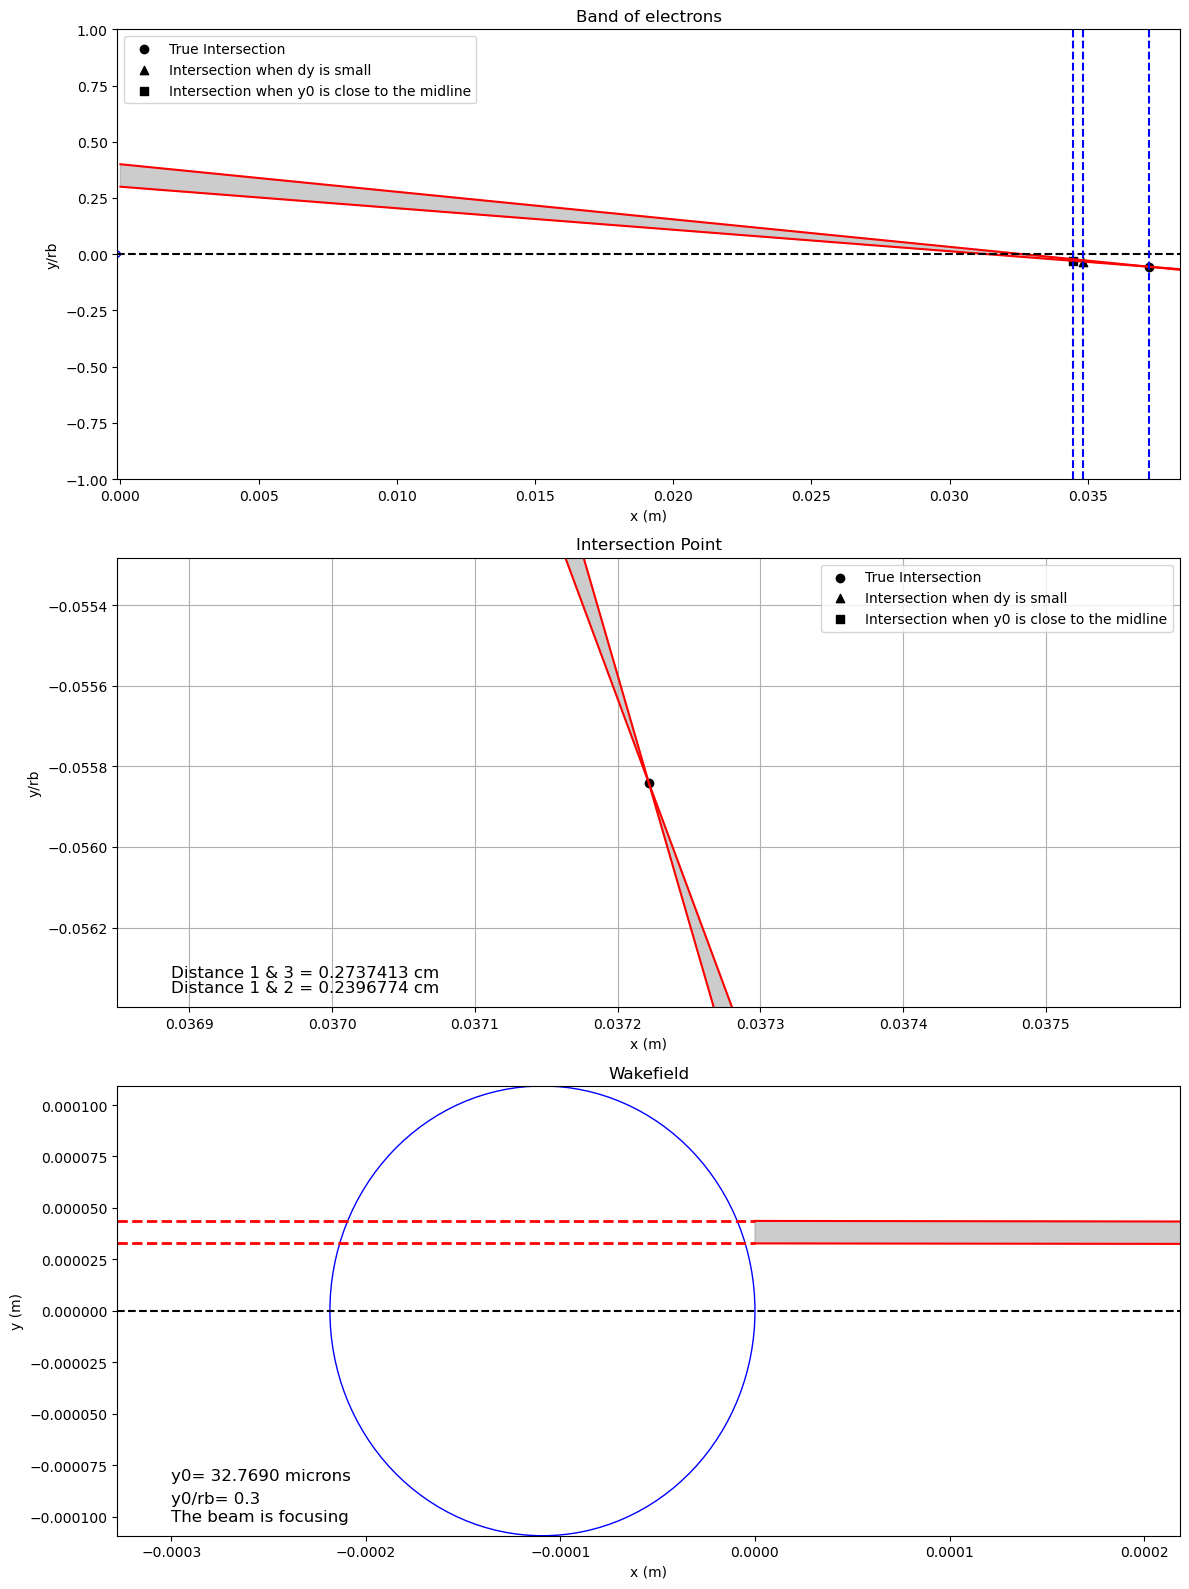

In [2]:
#Bryson Mariano
#5/29/2026

import numpy as np
import scipy.constants as constants
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import math

#Universal Parameters
me    = 9.1093837 * 10 ** (-31)  #kg
c     = 299792458.0              #m/s
ne    = 1 * 10.0**15 *10**6                 #number density
e0    = 8.85418782 * 10**(-12)   #m^-3 kg^-1s^4 A^2
e     = 1.60217663 * 10**(-19)   #coulombs
wp    = ((ne*e**2)/(me*e0)) ** (1/2)


#Define Parameters


gamma = 110                      #Unitless
k     = 0.475 *me*wp**2          #kg/s^2
rb    = 0.65  *c/wp               #c/omega_p   
px    = 110   *me*c                #mec

f0=((px)**2) / (gamma * me * k)


################################################################

y0rb= 0.3
dyrb= 0.1

y0 = y0rb*rb
dy = dyrb*rb


################################################################
#Create/define Focal Length Function

def f_cyl(i):
    return ( f0/(2*rb) *1/(np.sqrt(1-(i/rb)**2)))

def f_cylprime(i):
    return ( f0 /(2*rb) * (1-(i/rb)**2)**(-3/2) * (i/rb**2)  )
              

#############################################################

x = np.linspace(0, 2, 1000)

electron_low = -(y0/(f_cyl(y0)))*x +y0 

electron_high = - ((y0+dy)/(f_cyl(y0+dy)))*x + y0+dy 


##############################################################
#F-tilda Points 

f_Tilda = f_cyl(y0)*f_cyl(y0+dy)/(f_cyl(y0)-y0*(f_cyl(y0+dy)-f_cyl(y0))/dy) 

Intersect_y = -(y0/(f_cyl(y0)))*f_Tilda +y0

#dy goes to zero 
f_Tilda2 = f_cyl(y0)/(1-y0*(f_cylprime(y0)/f_cyl(y0)))

Intersect_y2 = -(y0/(f_cyl(y0)))* f_Tilda2 +y0


#Binomial Approx            
f_Tilda3 = f_cyl(y0)*(1+y0*(f_cylprime(y0)/f_cyl(y0))) 

Intersect_y3 = -(y0/(f_cyl(y0)))*f_Tilda3 +y0


#Distance Between Intersection Points
dist1_cm = np.sqrt((f_Tilda2 - f_Tilda)**2 + (Intersect_y2 - Intersect_y)**2) *100
dist2_cm = np.sqrt((f_Tilda3 - f_Tilda)**2 + (Intersect_y3 - Intersect_y)**2) *100


#Normalization:
Intersect_y = Intersect_y /rb
Intersect_y2 = Intersect_y2 /rb
Intersect_y3 = Intersect_y3 /rb
electron_low = electron_low /rb
electron_high = electron_high /rb

###########################################################################
#Slopes and focal lengths
print(f"The slope of the high electron is = {(y0+dy)/(f_cyl(y0+dy)):.4e}")
print(f"The focal length of the high electron is ={f_cyl(y0+dy):.4e}")
print()
print(f"The slope of the low electron is ={(y0)/f_cyl(y0):.4e}")
print(f"The focal length of the low electron is ={f_cyl(y0):.4e}")

print()
print(f"Point of Intersection(f_tilda): {f_Tilda:.4e} meters")
print(f"Height of Intersection:{Intersect_y:.4e} meters")
print()
print(f"Distance between f_tilda and f_tilda at small dy= {dist1_cm:.4e} cm")
print(f"Distance between f_tilda and f_tilda near midline= {dist2_cm:.4e} cm")
print()
print(f"y0 = {y0:.4e} meters")
print(f"dy = {dy:.4e} meters")
print()
if dist1_cm < dist2_cm:
    print("The firt approximation is better")
else:
    print("The second approximation is better")
print(y0/rb)


#Normalization:             #######################################################

#############################################################################
#make subplots

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 16))

#############################################################################
#Figure 1 shows the wakefield and lines

circle = plt.Circle((-rb/rb, 0), rb/rb, color='blue', fill=False)

# 3. Add the patch to the axis
ax1.add_patch(circle)


ax1.plot(x, electron_low, 'red')
ax1.plot(x, electron_high, 'red')
ax1.axhline(y=0, color='black', linestyle='--')

#f tilda Intersect point no approx     
ax1.scatter(f_Tilda, Intersect_y, color="black", marker="o", label='True Intersection')
ax1.axvline(x=f_Tilda, color='b', linestyle='--')

#f tilda Intersect point 1 approx     
ax1.scatter(f_Tilda2, Intersect_y2, color="black", marker="^", label='Intersection when dy is small')
ax1.axvline(x=f_Tilda2, color='b', linestyle='--')

#f tilda Intersect point 2 approx     
ax1.scatter(f_Tilda3, Intersect_y3, color="black", marker="s",  label='Intersection when y0 is close to the midline')
ax1.axvline(x=f_Tilda3, color='b', linestyle='--')


#Line distance
#ax1.plot([f_Tilda, f_Tilda2], [Intersect_y, Intersect_y2], color='green', linestyle='--')
#ax1.plot([f_Tilda, f_Tilda3], [Intersect_y, Intersect_y3], color='green', linestyle='--')
      
ax1.set_title("Band of electrons")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("y/rb")

# X limits#################################################################################################
if (f_Tilda > -rb):
    xmin = -rb
    xmax = f_Tilda * 1.03
else:
    xmin = f_Tilda * 1.03
    xmax = -f_Tilda * 1.03
    
    point1 = (x[2], electron_low[2])
    point2 = (x[3], electron_low[3])
    point3 = (x[2], electron_high[2])
    point4 = (x[3], electron_high[3])

    ax1.axline(point1, point2, color='red')
    ax1.axline(point3, point4, color='red')
    ax2.axline(point1, point2, color='red')
    ax2.axline(point3, point4, color='red')
    ax1.hlines(y=y0, xmin=f_Tilda * 1.03, xmax=0, color='red', linestyle='--', linewidth=2)
    ax1.hlines(y=y0+dy, xmin=f_Tilda * 1.03, xmax=0, color='red', linestyle='--', linewidth=2)
 ######################

ax1.set_xlim(min(xmin, xmax), max(xmin, xmax))

# Y limits
if np.abs(Intersect_y) > rb/rb:
    ymin = Intersect_y * 1.04 
    ymax = rb /rb
    if (f_Tilda < -rb/rb):
        ymin = -rb /rb
        ymax =  Intersect_y * 1.04 
else:
    ymin = -rb /rb
    ymax =  rb/rb

ax1.set_ylim(min(ymin, ymax), max(ymin, ymax))
ax1.legend()

#Fill in the Beam


ax1.fill_between(x, electron_low, electron_high, color='gray', alpha=0.4)


######################################################################
#Figure 2 shows the intersection

ax2.scatter(f_Tilda, Intersect_y, color="black", marker="o", label='True Intersection')
ax2.plot(x, electron_low, 'red')
ax2.plot(x, electron_high, 'red')

ax2.scatter(f_Tilda2, Intersect_y2, color="black", marker="^",label='Intersection when dy is small')

ax2.scatter(f_Tilda3, Intersect_y3, color="black", marker="s", label='Intersection when y0 is close to the midline')

# Line connecting them 
#ax2.plot([f_Tilda, f_Tilda2], [Intersect_y, Intersect_y2], color='green', linestyle='--')
#ax2.plot([f_Tilda, f_Tilda3], [Intersect_y, Intersect_y3], color='green', linestyle='--')

# Annotate distance

ax2.text(0.05, 0.060, f"Distance 1 & 2 = {dist1_cm:.7f} cm",
        transform=ax2.transAxes,
        fontsize=12,
        verticalalignment='top')

ax2.text(0.05, 0.095, f"Distance 1 & 3 = {dist2_cm:.7f} cm",
        transform=ax2.transAxes,
        fontsize=12,
        verticalalignment='top')


ax2.set_ylim(Intersect_y*1.01, Intersect_y*0.99)
ax2.set_xlim(f_Tilda*0.99 , f_Tilda*1.01)

ax2.fill_between(x, electron_low, electron_high, color='gray', alpha=0.4)

ax2.set_title("Intersection Point")
ax2.set_xlabel("x (m)")
ax2.set_ylabel("y/rb")
ax2.margins(x=0, y=0)
ax2.grid(True)
ax2.legend(loc='upper right')



#Figure 3 shows the wakefield 
circle = plt.Circle((-rb, 0), rb, color='blue', fill=False)

# 3. Add the patch to the axis
ax3.add_patch(circle)

ax3.plot(x, electron_low*rb, 'red')
ax3.plot(x, electron_high*rb, 'red')
ax3.axhline(y=0, color='black', linestyle='--')
ax3.set_ylim(-rb,rb)
ax3.set_xlim(-3*rb, 2*rb)
ax3.set_title("Wakefield")
ax3.text(0.05, 0.15, f"y0= {y0*10**6:.4f} microns",
        transform=ax3.transAxes,
        fontsize=12,
        verticalalignment='top')
ax3.text(0.05, 0.1, f"y0/rb= {y0/rb} ",
        transform=ax3.transAxes,
        fontsize=12,
        verticalalignment='top')
if f_Tilda < rb:
    ax3.text(0.05, 0.05, f"The beam is defocusing",
        transform=ax3.transAxes,
        fontsize=12,
        verticalalignment='top')
else:
    ax3.text(0.05, 0.060, f"The beam is focusing",
        transform=ax3.transAxes,
        fontsize=12,
        verticalalignment='top')

ax3.fill_between(x, electron_low*rb, electron_high*rb, color='gray', alpha=0.4)
ax3.hlines(y=y0, xmin=-3*rb, xmax=0, color='red', linestyle='--', linewidth=2)
ax3.hlines(y=y0+dy, xmin=-3*rb, xmax=0, color='red', linestyle='--', linewidth=2)

ax3.set_xlabel("x (m)")
ax3.set_ylabel("y (m)")

plt.tight_layout()
plt.show()
